## Exploratory Data Analysis

In [79]:

import pandas as pd

df = pd.read_csv("train.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [80]:
df.info()

df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [81]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [82]:
# Se observa la presencia de valores faltantes en el dataset, especialmente en las columnas "Age" y "Cabin". Esto podría afectar el análisis y la construcción de modelos predictivos, por lo que se deben considerar estrategias para manejar estos valores faltantes, como la imputación o la eliminación de filas/columnas con demasiados valores faltantes.
df["Age"].fillna(df["Age"].median(), inplace=True)

df.drop("Cabin", axis=1, inplace=True)

df["Embarked"].fillna(df["Embarked"].mode()[0], inplace=True)

C:\Users\alons\AppData\Local\Temp\ipykernel_22100\1170587611.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Age"].fillna(df["Age"].median(), inplace=True)
C:\Users\alons\AppData\Local\Temp\ipykernel_22100\1170587611.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For e

In [83]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

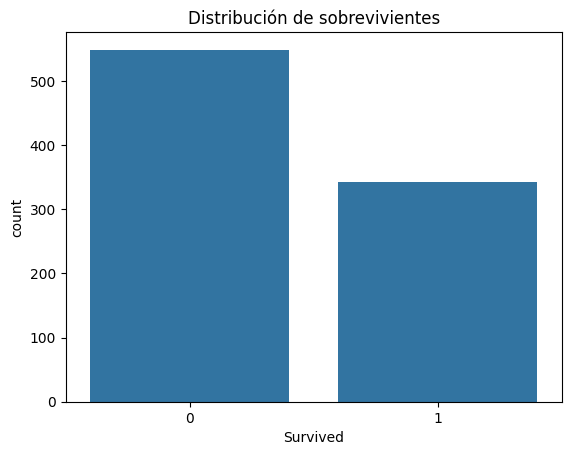

In [84]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="Survived", data=df)
plt.title("Distribución de sobrevivientes")
plt.show()

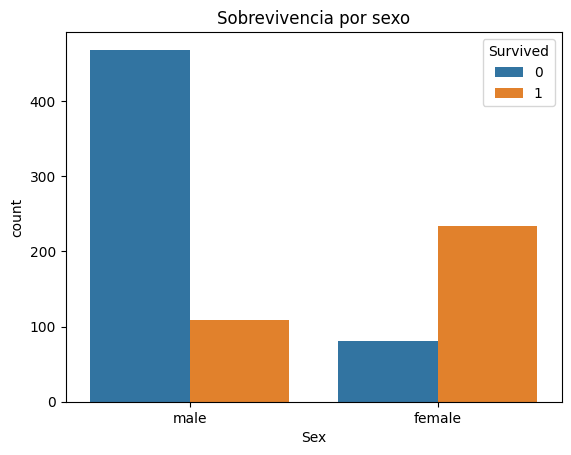

In [85]:
sns.countplot(x="Sex", hue="Survived", data=df)
plt.title("Sobrevivencia por sexo")
plt.show()

Se puede visualizar que existe mayor número de no sobrevivientes de género masculino en comparación con los no sobrevivientes de género femenino, también se puede notar que existen más sobrevivientes mujeres que hombres.

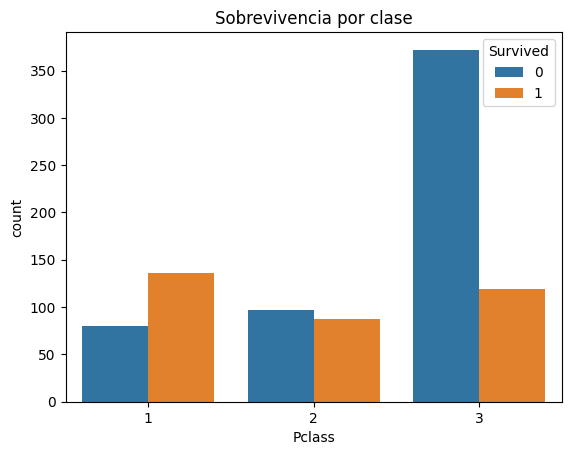

In [86]:
sns.countplot(x="Pclass", hue="Survived", data=df)
plt.title("Sobrevivencia por clase")
plt.show()

Se puede notar que hay un leve número mayor de sobrevivientes de clase 1 con los de la clase 2 y 3, y también existe un mayor número de no sobrevientes de clase 3 en comparación con la clase 1 y 2.

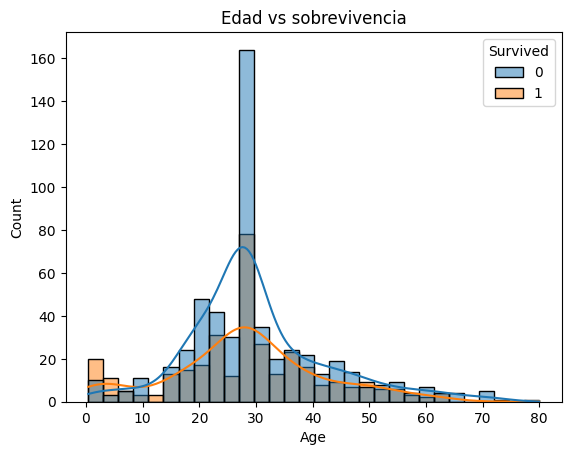

In [87]:
sns.histplot(data=df, x="Age", hue="Survived", bins=30, kde=True)
plt.title("Edad vs sobrevivencia")
plt.show()

La mayor edad de sobrevivencia está entre los 29 y 30 años, y los no sobrevivientes también están en ese rango, por lo que se puede notar es que había un mayor número de pasajeros de esa edad.

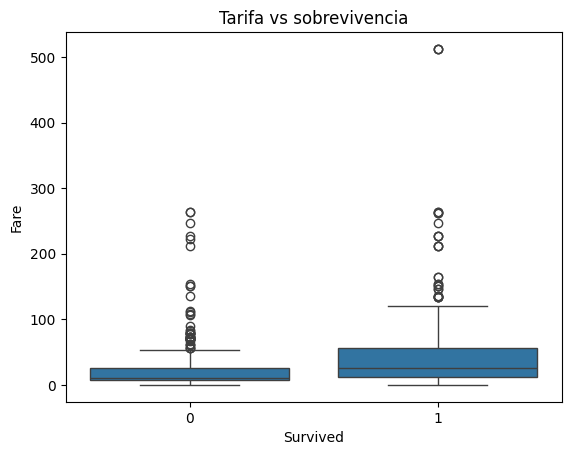

In [88]:
sns.boxplot(x="Survived", y="Fare", data=df)
plt.title("Tarifa vs sobrevivencia")
plt.show()

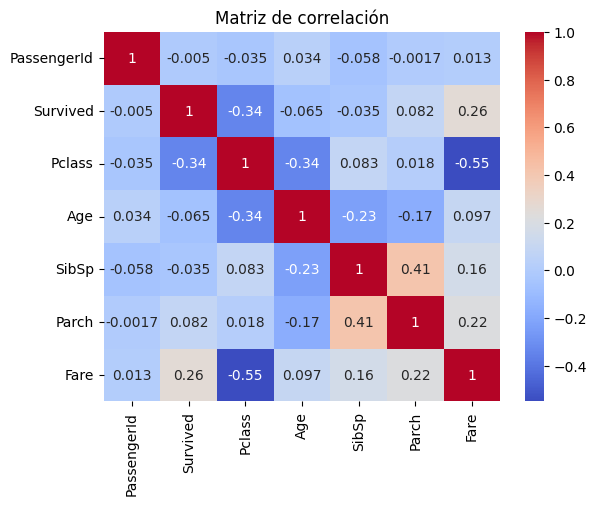

In [89]:
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Matriz de correlación")
plt.show()